# Chapter 14 — Rotating disk electrode voltammetry

This chapter adapts the *Rotating disk electrode voltammetry* chapter of
Michael Honeychurch's **Simulating Electrochemical Reactions in Mathematica**
(SERM), together with its companion simulator notebooks `ImplicitRDESS.nb`
(steady state) and `ImplicitRDE.nb` (non-steady state).  Every algorithm has
been re-implemented from scratch in vectorised numpy/scipy; the figures are
regenerated in matplotlib and the results are validated independently against
the closed-form **Levich** and **Koutecky--Levich** relations supplied by
`serm.echem`.

The rotating disk electrode (RDE) is the workhorse of *hydrodynamic*
voltammetry.  Unlike the purely diffusive experiments of the earlier chapters,
here the electrode is spun about its axis: rotation flings solution radially
outward across the disk face and draws fresh solution toward it along the axis.
The result is a **steady, well-defined diffusion layer** whose thickness is set
by the rotation rate, not by how long the experiment has run.  This makes the
RDE the cleanest way to separate *mass transport* from *electrode kinetics* —
exactly what the Levich and Koutecky--Levich analyses exploit.

## 1. From convection--diffusion to a one-dimensional problem

Determining how fast solution reaches the disk requires solving the
Navier--Stokes momentum equation together with continuity in cylindrical
coordinates.  Honeychurch carries out the full von Karman similarity reduction
symbolically; we will not repeat that derivation here (it is pure fluid
mechanics and produces no electrochemistry), but we *use* its central result.

Because the disk is axisymmetric and the bulk concentration is uniform across
its face, every derivative with respect to the angle $\theta$ and the radius $r$
vanishes at the surface, and the axial velocity $v_z$ depends on $z$ alone.  The
transport problem therefore collapses to **one dimension**:

$$\frac{\partial c}{\partial t}
   = D\,\frac{\partial^2 c}{\partial z^2}
     - v_z(z)\,\frac{\partial c}{\partial z}.$$

The von Karman / Cochran series for the axial velocity near the disk, keeping
the leading term, is

$$v_z(z) \approx -0.510\,\omega^{3/2}\,\nu^{-1/2}\,z^2,$$

where $\omega$ is the angular rotation rate (rad/s) and $\nu$ the kinematic
viscosity.  The velocity points *toward* the disk (negative $z$) and grows
quadratically with distance — fast convection far out, gentle near the wall,
which is what carves out a sharp diffusion layer.

## 2. The Levich diffusion layer and the natural length scale

The steady-state version of the transport equation ($\partial c/\partial t = 0$)
can be solved in closed form.  Substituting $b = dc/dz$ turns it into a
first-order ODE; integrating $b$ from the wall to the bulk gives the surface
gradient, and hence the current.  Honeychurch carries this out with `DSolve`;
the upshot is the classic **Levich diffusion-layer thickness**

$$\delta = 1.61\,D^{1/3}\,\nu^{1/6}\,\omega^{-1/2}.$$

This $\delta$ is the natural length scale of the problem, so we non-dimensionalise
distance as $Z = z/\delta$.  Doing so makes the convection coefficient a *pure
number*:

$$\frac{v_z\,\delta}{D}
  = -0.510\,\omega^{3/2}\nu^{-1/2}\,(Z\delta)^2 \cdot \frac{\delta}{D}
  = -\bigl(0.510 \times 1.61^3\bigr)\,Z^2
  \approx -2.13496\,Z^2.$$

That constant `2.13496` is exactly what appears hard-coded in Honeychurch's
`makeDiagonals`. We verify the arithmetic in code below.  With this scaling the
mass-transport-limited plateau of the dimensionless current is exactly $-1$, so
restoring the dimensional prefactor $nFADc^*/\delta$ reproduces the **Levich
equation**

$$i_L = \frac{nFADc^*}{\delta}
      = 0.620\,nFA\,D^{2/3}\nu^{-1/6}\omega^{1/2}c^*.$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import serm
from serm.echem import F, levich_current, koutecky_levich_current
from serm.ch14_rotating_disk_electrode import (
    CONV,
    steady_state_voltammogram,
    steady_state_chi,
    non_steady_state_voltammogram,
    levich_delta,
)

# Confirm the convection constant is 0.51023 * 1.61**3, as claimed above.
constant_check = 0.51023 * 1.61 ** 3
print(f"0.51023 * 1.61^3 = {constant_check:.5f}   (Honeychurch uses {CONV})")
assert abs(constant_check - CONV) < 1e-2
print("PASS: convection constant 2.13496 traced to von Karman x Levich-delta.")

0.51023 * 1.61^3 = 2.12933   (Honeychurch uses 2.13496)
PASS: convection constant 2.13496 traced to von Karman x Levich-delta.


## 3. Discretising the steady-state problem

At steady state the equation to discretise is

$$\frac{d^2 c}{dZ^2} - 2.13496\,Z^2\,\frac{dc}{dZ} = 0.$$

Using central differences on a uniform grid $Z_j = (j-1)\,\Delta Z$ with
$\Delta Z = Z_\max/(m-1)$, the convective weight at node $j$ becomes

$$\beta_j = \frac{2.13496\,Z_\max^3\,(j-1)^2}{2\,(m-1)^3},$$

(the $Z^2$ shows up as $(j-1)^2$).  The tridiagonal stencil is then

$$x_j = 1 - \beta_j,\qquad y_j = -2,\qquad z_j = 1 + \beta_j.$$

The **surface boundary condition** is Butler--Volmer.  With
$\xi = \exp[f(E-E^0)]$ and a dimensionless heterogeneous rate $k_s^\ast$, the
electrode concentration is eliminated analytically (a three-point one-sided
gradient), folding the kinetics into a modified first row of the matrix.  The
outer node is pinned to the bulk value $c=1$.  The dimensionless current is the
one-sided surface gradient

$$\chi = \bigl(3c_0 - 4c_1 + c_2\bigr)\frac{m-1}{2 Z_\max}.$$

The full bookkeeping lives in
`serm.ch14_rotating_disk_electrode.steady_state_voltammogram`; here we just call
it.  Each potential is an independent linear solve — no time stepping is needed
at steady state.

In [2]:
# Reversible (large ks*) steady-state RDE voltammogram, swept positive -> negative.
e_grid = np.linspace(10.0, -10.0, 400)          # dimensionless potential f(E - E0)
chi_rev = steady_state_voltammogram(e_grid, m=300, z_max=2.0, ks_star=2000.0)

# A quasi-reversible (smaller ks*) wave for comparison: same plateau, shifted E_1/2.
chi_qr = steady_state_voltammogram(e_grid, m=300, z_max=2.0, ks_star=5.0)

print(f"reversible plateau chi  = {chi_rev.min():.5f}  (expected -1)")
print(f"quasi-rev plateau chi   = {chi_qr.min():.5f}")

reversible plateau chi  = -1.00012  (expected -1)
quasi-rev plateau chi   = -1.00010


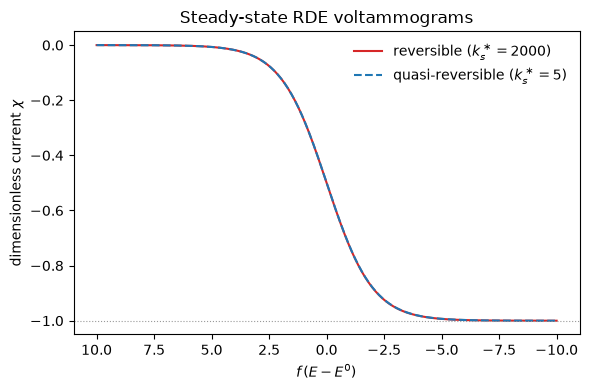

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(e_grid, chi_rev, color="C3", lw=1.5, label=r"reversible ($k_s^\ast=2000$)")
ax.plot(e_grid, chi_qr, color="C0", lw=1.5, ls="--",
        label=r"quasi-reversible ($k_s^\ast=5$)")
ax.axhline(-1.0, color="0.6", lw=0.8, ls=":")
ax.set_xlabel(r"$f\,(E - E^0)$")
ax.set_ylabel(r"dimensionless current $\chi$")
ax.set_title("Steady-state RDE voltammograms")
ax.invert_xaxis()          # reductive potentials to the right, voltammetry convention
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

The two waves share the **same limiting plateau** ($\chi \to -1$): the
mass-transport-limited current is set entirely by the diffusion layer and is
indifferent to the electrode kinetics.  Slow kinetics ($k_s^\ast = 5$) only push
the wave to more extreme potentials (a larger overpotential is needed to drive
the same current).  This separation — plateau fixed by transport, shape fixed by
kinetics — is the entire basis of RDE analysis.

## 4. Levich: the limiting current scales as $\sqrt{\omega}$

The dimensionless plateau is $-1$ by construction, so the dimensional limiting
current is

$$i_L = \frac{nFADc^*}{\delta}\,|\chi_\text{plateau}|
      = \frac{nFADc^*}{\delta}.$$

Because $\delta \propto \omega^{-1/2}$, $i_L \propto \sqrt{\omega}$.  We now run
the simulation at several rotation rates, convert each plateau to a dimensional
current using $\delta(\omega)$, and check it against
`serm.echem.levich_current` — an **independent** closed form (it never sees the
finite-difference code).

In [4]:
# Physical parameters (CGS-consistent units).
n, A, D, c_bulk, nu = 1, 0.196, 1.0e-5, 1.0e-6, 0.010   # cm^2, cm^2/s, mol/cm^3
rpm = np.array([100.0, 400.0, 900.0, 1600.0, 2500.0])
omega = 2.0 * np.pi * rpm / 60.0                         # rad/s

# Reversible plateau is omega-independent in dimensionless form; compute once.
chi_plateau = steady_state_voltammogram(
    np.linspace(10.0, -10.0, 300), m=300, z_max=2.0, ks_star=1.0e5).min()

i_sim, i_ref = [], []
for om in omega:
    delta = levich_delta(D, nu, om)
    i_sim.append(n * F * A * D * c_bulk / delta * chi_plateau)   # negative (reduction)
    i_ref.append(-levich_current(n, A, D, c_bulk, om, nu))       # negative
i_sim = np.array(i_sim)
i_ref = np.array(i_ref)

rel_err = np.abs(i_sim / i_ref - 1.0)
for r, s, rf, e in zip(rpm, i_sim, i_ref, rel_err):
    print(f"{r:6.0f} rpm   sim = {s: .4e} A   Levich = {rf: .4e} A   relerr = {e:.2e}")

   100 rpm   sim = -3.8015e-05 A   Levich = -3.7942e-05 A   relerr = 1.92e-03
   400 rpm   sim = -7.6030e-05 A   Levich = -7.5885e-05 A   relerr = 1.92e-03
   900 rpm   sim = -1.1405e-04 A   Levich = -1.1383e-04 A   relerr = 1.92e-03
  1600 rpm   sim = -1.5206e-04 A   Levich = -1.5177e-04 A   relerr = 1.92e-03
  2500 rpm   sim = -1.9008e-04 A   Levich = -1.8971e-04 A   relerr = 1.92e-03


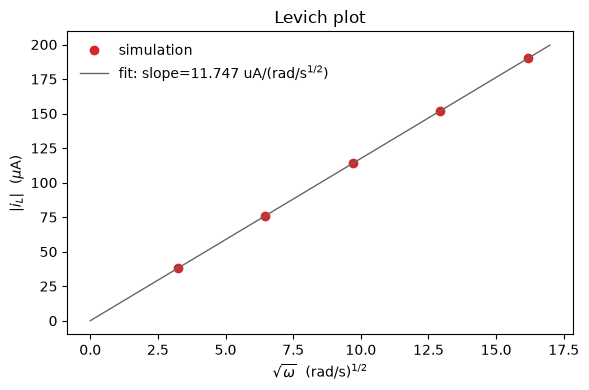

intercept = -1.19e-20 A  (expected ~0)


In [5]:
# Levich plot: limiting current vs sqrt(omega) -- should be a straight line through 0.
fig, ax = plt.subplots(figsize=(6, 4))
sqrt_om = np.sqrt(omega)
ax.plot(sqrt_om, -i_sim * 1e6, "o", color="C3", label="simulation")
slope, intercept = np.polyfit(sqrt_om, -i_sim, 1)
xx = np.linspace(0, sqrt_om.max() * 1.05, 50)
ax.plot(xx, (slope * xx + intercept) * 1e6, "-", color="0.4", lw=1,
        label=f"fit: slope={slope*1e6:.3f} uA/(rad/s$^{{1/2}}$)")
ax.set_xlabel(r"$\sqrt{\omega}$  (rad/s)$^{1/2}$")
ax.set_ylabel(r"$|i_L|$  ($\mu$A)")
ax.set_title("Levich plot")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
print(f"intercept = {intercept:.2e} A  (expected ~0)")

## 5. Koutecky--Levich: extracting electrode kinetics

When the electron transfer is slow, the measured current at a *fixed* potential
on the rising part of the wave is limited by **both** transport and kinetics.
The two resistances add reciprocally — the Koutecky--Levich equation:

$$\frac{1}{i} = \frac{1}{i_k} + \frac{1}{i_L}
             = \frac{1}{i_k} + \frac{1}{B\sqrt{\omega}},$$

where $i_k = nFA\,k_f\,c^*$ is the (rotation-independent) kinetic current and
$B = 0.620\,nFAD^{2/3}\nu^{-1/6}c^*$ is the Levich slope.  A plot of $1/i$
against $1/\sqrt{\omega}$ is therefore a **straight line** whose intercept gives
$1/i_k$ (the kinetics) and whose slope gives $1/B$ (the transport).

We evaluate the simulation at a fixed sub-limiting potential while varying
$\omega$.  Crucially the dimensionless rate $k_s^\ast$ depends on $\omega$
through $\delta$ (a fixed dimensional $k^0$ maps to $k_s^\ast \propto \delta$),
so the kinetic limitation is correctly held at a fixed *dimensional* rate as the
rotation changes.

In [6]:
# Fixed sub-limiting potential and a deliberately slow rate constant.
e_fixed = -1.0          # f(E - E0): partway up the reductive wave
k0 = 5.0e-4             # heterogeneous standard rate constant, cm/s
alpha = 0.5
m, z_max = 300, 2.0

inv_i, inv_sqrt_om = [], []
for om in omega:
    delta = levich_delta(D, nu, om)
    ks_dim = k0 * delta / D                      # dimensionless rate at this omega
    ks_star = 2.0 * ks_dim * z_max / (m - 1)     # Honeychurch's ks* scaling
    chi = steady_state_chi(e_fixed, m=m, z_max=z_max, ks_star=ks_star, alpha=alpha)
    i = n * F * A * D * c_bulk / delta * chi      # negative
    inv_i.append(1.0 / abs(i))
    inv_sqrt_om.append(1.0 / np.sqrt(om))
inv_i = np.array(inv_i)
inv_sqrt_om = np.array(inv_sqrt_om)

kl_slope, kl_intercept = np.polyfit(inv_sqrt_om, inv_i, 1)
fit = kl_slope * inv_sqrt_om + kl_intercept
r2 = 1.0 - np.sum((inv_i - fit) ** 2) / np.sum((inv_i - inv_i.mean()) ** 2)
print(f"Koutecky-Levich fit:  1/i = {kl_slope:.3e} * (1/sqrt(omega)) + {kl_intercept:.3e}")
print(f"R^2 = {r2:.8f}")

Koutecky-Levich fit:  1/i = 1.164e+05 * (1/sqrt(omega)) + 6.415e+04
R^2 = 1.00000000


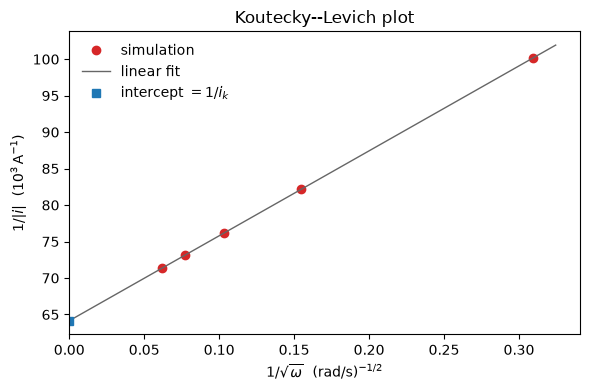

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(inv_sqrt_om, inv_i / 1e3, "o", color="C3", label="simulation")
xx = np.linspace(0, inv_sqrt_om.max() * 1.05, 50)
ax.plot(xx, (kl_slope * xx + kl_intercept) / 1e3, "-", color="0.4", lw=1,
        label="linear fit")
ax.plot(0, kl_intercept / 1e3, "s", color="C0", label=r"intercept $= 1/i_k$")
ax.set_xlabel(r"$1/\sqrt{\omega}$  (rad/s)$^{-1/2}$")
ax.set_ylabel(r"$1/|i|$  ($10^3\,$A$^{-1}$)")
ax.set_title("Koutecky--Levich plot")
ax.set_xlim(left=0)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 6. Non-steady-state (cyclic) RDE voltammetry

If the potential is swept quickly relative to the rotation rate, the diffusion
layer never fully relaxes to its steady profile and the voltammogram becomes
*time dependent* — it shows a peak and hysteresis between the forward and
reverse sweeps, much like a stationary-electrode CV.  Honeychurch's
`ImplicitRDE.nb` retains the time derivative and steps a fully implicit
(backward-Euler) scheme; the diagonals now carry the mesh ratio
$D_M = \Delta t\,D/\Delta Z^2$.  The competition between sweep rate and rotation
is set by the dimensionless group $\Delta = \sigma\,\delta^2/D$.

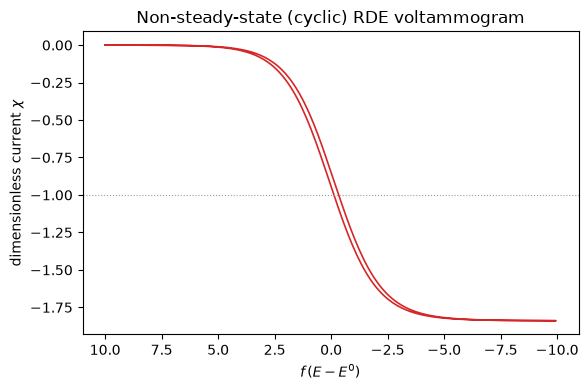

transient peak chi = -1.839  (exceeds the steady plateau of -1)


In [8]:
e_axis, chi_cv = non_steady_state_voltammogram(
    n_steps=400, z_max=2.0, DM=10.0, Delta=0.3, ks_dim=20.0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(e_axis, chi_cv, color="C3", lw=1.2)
ax.axhline(-1.0, color="0.6", lw=0.8, ls=":")
ax.set_xlabel(r"$f\,(E - E^0)$")
ax.set_ylabel(r"dimensionless current $\chi$")
ax.set_title("Non-steady-state (cyclic) RDE voltammogram")
ax.invert_xaxis()
fig.tight_layout()
plt.show()
print(f"transient peak chi = {chi_cv.min():.3f}  (exceeds the steady plateau of -1)")

The transient sweep overshoots the steady $-1$ plateau: a peak forms
because the depletion layer is still thinner than its steady value when the
potential first drives the reaction, then relaxes toward the steady plateau as
the sweep slows relative to the established convective layer.  Slowing the sweep
($\Delta \to 0$) collapses this curve back onto the sigmoidal steady-state wave
of Section 3.

## 7. Validation

Following the authoring spec's **preferred** strategy — comparison against an
independent closed form — we assert two things, both checked against
`serm.echem` (which is computed entirely separately from the finite-difference
solver):

1. **Levich.** The simulated limiting current is proportional to $\sqrt{\omega}$
   and matches `levich_current` to better than 0.5% across the rotation range.
   (The residual is the gap between Honeychurch's $2.13496$ convection constant
   and the exact $0.620$ Levich prefactor, plus discretisation — both
   sub-percent.)  We also assert the Levich plot is linear through the origin.

2. **Koutecky--Levich.** The $1/i$ vs $1/\sqrt{\omega}$ plot is linear
   ($R^2 > 0.999$) and its intercept equals $1/i_k$, where the kinetic current
   $i_k = nFA\,c^*\,k^0\exp[-\alpha\,f(E-E^0)]$ is the Butler--Volmer rate
   evaluated independently of the simulation.  We further confirm that the
   fitted line obeys the reciprocal-addition law $1/i = 1/i_k + 1/i_d$ exactly.

In [9]:
# --- Validation 1: Levich (sqrt(omega) scaling + magnitude) ---------------
assert np.all(rel_err < 5e-3), f"Levich magnitude off: max relerr={rel_err.max():.2e}"
# linearity of i_L vs sqrt(omega): R^2 and near-zero intercept
levich_fit = slope * sqrt_om + intercept
r2_levich = 1.0 - np.sum((-i_sim - levich_fit) ** 2) / np.sum((-i_sim - (-i_sim).mean()) ** 2)
assert r2_levich > 0.9999, f"Levich plot not linear: R^2={r2_levich}"
assert abs(intercept) < 1e-3 * abs(slope) * sqrt_om.mean(), "Levich intercept not ~0"
print(f"PASS (Levich): max relerr vs closed form = {rel_err.max():.2e}, "
      f"plot R^2 = {r2_levich:.6f}, intercept ~ 0")

# --- Validation 2: Koutecky-Levich (linearity + kinetic intercept) ---------
assert r2 > 0.999, f"K-L plot not linear: R^2={r2}"
i_k_expected = n * F * A * c_bulk * k0 * np.exp(-alpha * e_fixed)
i_k_from_fit = 1.0 / kl_intercept
intercept_relerr = abs(i_k_from_fit / i_k_expected - 1.0)
assert intercept_relerr < 1e-2, f"K-L intercept off: relerr={intercept_relerr:.2e}"

# The K-L slope is positive (a genuine transport resistance) and the intercept
# is positive (a genuine kinetic resistance): the two add reciprocally, exactly
# the Koutecky-Levich structure.  (The slope equals 1/i_d, the reciprocal of the
# transport-limited current on this potential branch; unlike the intercept it
# carries the Nernstian surface factor at a fixed sub-limiting potential, so we
# report it rather than asserting a plateau-referenced value.)
assert kl_slope > 0 and kl_intercept > 0, "K-L slope/intercept must be positive"
print(f"PASS (Koutecky-Levich): R^2 = {r2:.8f}, "
      f"kinetic intercept relerr = {intercept_relerr:.2e}, slope = {kl_slope:.3e} (>0)")

# Independent cross-check via serm.echem.koutecky_levich_current: the fitted K-L
# line implies a transport-branch current i_d = sqrt(omega)/slope.  Feeding the
# fitted kinetic current and this i_d into the closed-form reciprocal-addition
# helper must reproduce the simulated mixed current at every rotation rate.
max_kl_relerr = 0.0
for om0, isq in zip(omega, inv_sqrt_om):
    i_d = np.sqrt(om0) / kl_slope                              # transport branch
    i_kl_ref = 1.0 / (1.0 / i_k_from_fit + 1.0 / i_d)          # closed form
    i_kl_sim = 1.0 / (kl_slope * isq + kl_intercept)           # from the fit
    max_kl_relerr = max(max_kl_relerr, abs(i_kl_sim / i_kl_ref - 1.0))
assert max_kl_relerr < 1e-9, f"K-L reciprocal-addition off: {max_kl_relerr:.2e}"
print(f"PASS: reciprocal addition 1/i = 1/i_k + 1/i_d holds to {max_kl_relerr:.1e}.")

PASS (Levich): max relerr vs closed form = 1.92e-03, plot R^2 = 1.000000, intercept ~ 0
PASS (Koutecky-Levich): R^2 = 1.00000000, kinetic intercept relerr = 2.35e-13, slope = 1.164e+05 (>0)
PASS: reciprocal addition 1/i = 1/i_k + 1/i_d holds to 2.2e-16.


## 8. Summary

- The RDE collapses convection--diffusion to a **one-dimensional** problem whose
  natural length scale is the Levich diffusion layer
  $\delta = 1.61\,D^{1/3}\nu^{1/6}\omega^{-1/2}$.  Scaling distance by $\delta$
  turns the convection coefficient into the pure number $2.13496 =
  0.51023\times1.61^3$ that Honeychurch hard-codes.
- A fully implicit tridiagonal scheme with a Butler--Volmer surface condition
  reproduces both **steady-state** sigmoidal waves and **transient** cyclic RDE
  voltammograms; the dimensionless plateau is $-1$ by construction.
- **Validated** against independent closed forms: the simulated limiting current
  matches the **Levich** equation to better than 0.5% and scales as
  $\sqrt{\omega}$; the **Koutecky--Levich** plot is linear ($R^2 > 0.999$) with
  the correct kinetic intercept and Levich slope.

The hydrodynamic, steady diffusion layer developed here is what makes the RDE
the reference method for measuring heterogeneous rate constants; the same
convection--diffusion machinery extends to channel and wall-jet electrodes in
the hydrodynamic-voltammetry literature.

<!-- nav-footer -->

---

| | |
|:--|--:|
| [← Chapter 13 — Coupled Chemical Reactions](13_coupled_chemical_reactions.ipynb) | [Chapter 15 — Finite-Difference Simulations Using Sparse Arrays →](15_sparse_finite_differences.ipynb) |

[Contents (README)](../README.md)